In this notebook, we'll test out feature engineering for the photometric redshift problem, and take a look at the feature importance. 

Copyright: Viviana Acquaviva (2023); see also other data credits below.

Modifications by Julieta Gruszko (2025)

License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

The problem is inspired by [this paper](https://arxiv.org/abs/1903.08174), for which the data are public and available [here](http://d-scholarship.pitt.edu/36064/).

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)


font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': True})
matplotlib.rcParams['figure.dpi'] = 300

In [2]:
!pip install xgboost # install xgboost if you don't have it

In [3]:
import xgboost as xgb

In [4]:
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor

We read in the selection of data as in previous notebooks.

In [5]:
sel_features = pd.read_csv('../Data/sel_features.csv', sep = '\t')

In [6]:
sel_target = pd.read_csv('../Data/sel_target.csv')

In [7]:
sel_features.shape

(6307, 6)

In [8]:
sel_target.values.ravel() #changes shape to 1d row-like array

array([1.0034, 0.9023, 0.4242, ..., 0.3703, 0.371 , 0.7333])

### I'll demonstrate how to check the feature importance using Random Forests as an example.

In [9]:
model = RandomForestRegressor(max_features=4, n_estimators=200) #I need to re-seed the random state

After the model has been fit, it will have the attribute "feature\_importances\_". These are calculated based on the decrease of impurity method. We can look at the feature importance using the following code:

In [10]:
model.fit(sel_features, sel_target.values.ravel()) 

#note: this is not doing any train/test split, but fitting the entire data set 

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
model.feature_importances_

array([0.20296234, 0.13495961, 0.29935213, 0.15308929, 0.09554111,
       0.11409552])

The code below plots the feature importances. You'll need to adapt it to show the results for multiple models, so you can compare them.

Feature ranking:
1. feature: r_apercor, 2 (0.299352)
2. feature: u_apercor, 0 (0.202962)
3. feature: i_apercor, 3 (0.153089)
4. feature: g_apercor, 1 (0.134960)
5. feature: y_apercor, 5 (0.114096)
6. feature: z_apercor, 4 (0.095541)


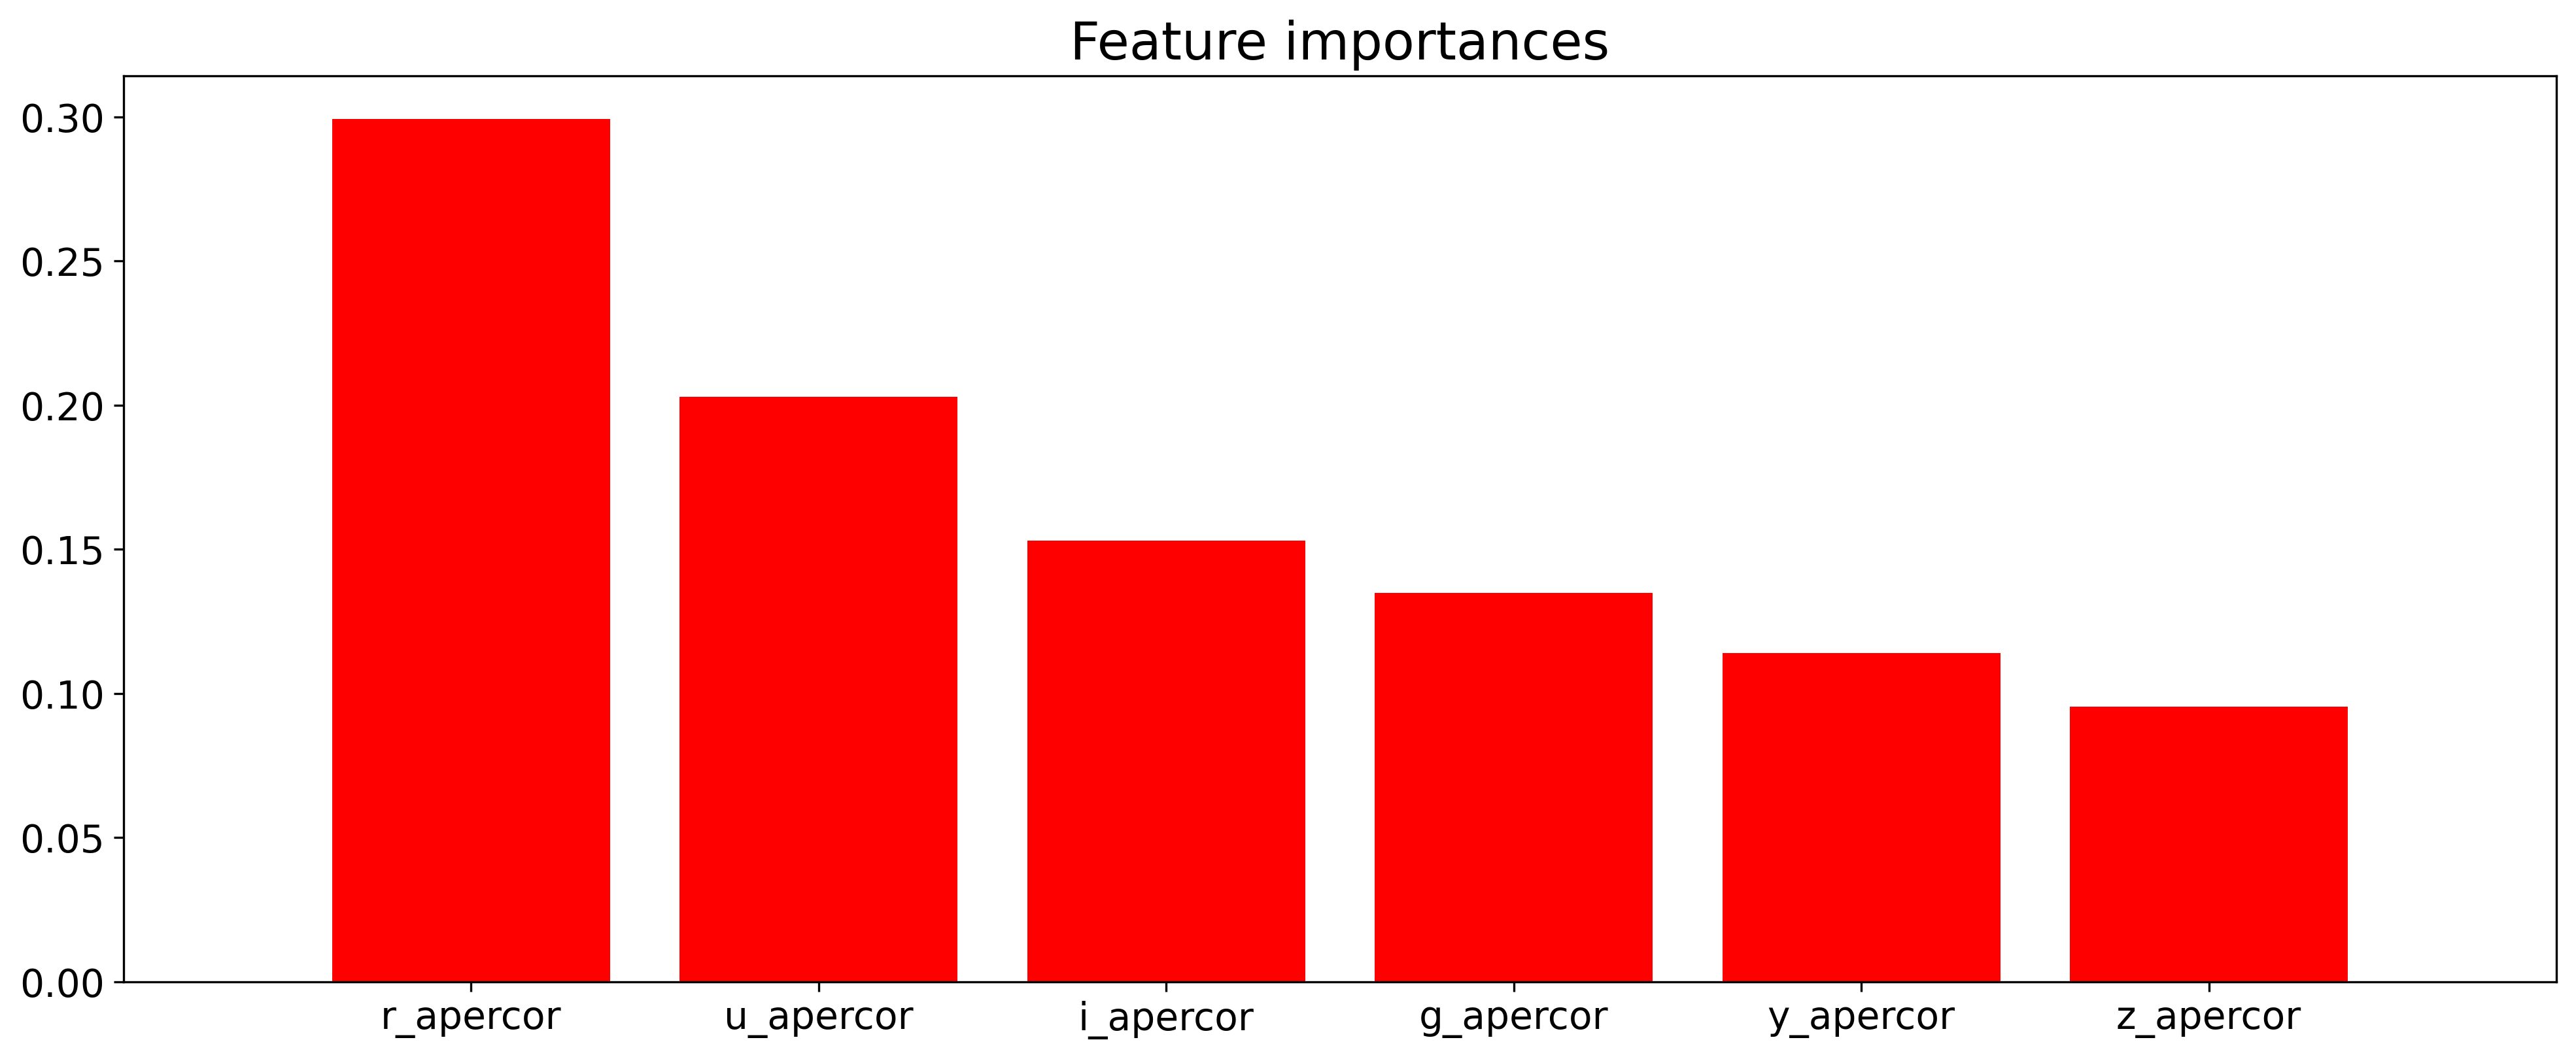

In [12]:
importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(sel_features.shape[1]):
    print("%d. feature: %s, %d (%f)" % (f + 1, sel_features.columns[indices[f]], indices[f], importances[indices[f]]))

# Plot the feature importances of the forest
plt.figure(figsize=(16,6))
plt.title("Feature importances")
plt.bar(range(sel_features.shape[1]), importances[indices],
       color="r", align="center")
plt.xticks(range(sel_features.shape[1]), sel_features.columns[indices])
plt.xlim([-1, sel_features.shape[1]])
plt.show()

### Your turn! 

### Step 1: Feature Engineering
In the paper that we used as a reference (https://arxiv.org/abs/1903.08174), the authors actually use colors, not magnitudes, as features (or to be precise: one magnitude and five colors). Find in the paper the exact list of features (hint: it's in Section 7), and generate the new features to match what is done there. Note: a color is the ratio of brightness in two bands, but because the brightness in each band is expressed in magnitudes, which is a logarithmic unit (i.e. it's proportional to log(luminosity)), you can obtain colors by subtracting two bands.

Then, compare the performance of an $\textbf{optimized}$ Random Forest model using 3 options for features:
- Version 1: 6 magnitudes, as demonstrated in Studio 8. No need to repeat the work from studio, you can just cite the result you found.
- Version 2: 1 magnitude and 5 colors, as described in the paper.
- Version 3: Include all the features from Version 1 and Version 2, yielding 6 magnitudes and 5 colors as your full set of features. 

Compare the outlier fraction and $\sigma_{NMAD}$ for the 3 versions, taking into account the uncertainties.

>Version 1: 

>OLF avg/std:, 0.05708, 0.00081

>NMAD avg/std:, 0.03687, 0.00041

In [13]:
features_v2 = pd.DataFrame()
features_v2['i'] = sel_features['i_apercor']
features_v2['u-g'] = sel_features['u_apercor'] - sel_features['g_apercor']
features_v2['g-r'] = sel_features['g_apercor'] - sel_features['r_apercor']
features_v2['r-i'] = sel_features['r_apercor'] - sel_features['i_apercor']
features_v2['i-z'] = sel_features['i_apercor'] - sel_features['z_apercor']
features_v2['z-y'] = sel_features['z_apercor'] - sel_features['y_apercor']

features_v1 = sel_features.copy()

features_v3 = pd.concat([features_v1, features_v2.drop(columns=['i'])], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    features_v3, sel_target.values.ravel(), test_size=0.2, random_state=42
)

def nmad(y_true, y_pred):
    return 1.4826 * np.median(np.abs((y_pred - y_true) / (1 + y_true)))

def outlier_fraction(y_true, y_pred, threshold=0.15):
    return np.mean(np.abs((y_pred - y_true)/(1 + y_true)) > threshold)

def compute_metrics_with_uncertainty(model, X_test, y_test, n_bootstrap=1000):
    nmad_values = []
    olf_values = []
    y_pred = model.predict(X_test)
    n = len(y_test)
    rng = np.random.default_rng(42)
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, replace=True)
        nmad_values.append(nmad(y_test[idx], y_pred[idx]))
        olf_values.append(outlier_fraction(y_test[idx], y_pred[idx]))
    return np.mean(nmad_values), np.std(nmad_values), np.mean(olf_values), np.std(olf_values)

rf_model = RandomForestRegressor(n_estimators=200, max_features=4, random_state=42)
rf_model.fit(X_train, y_train)

mean_nmad, std_nmad, mean_olf, std_olf = compute_metrics_with_uncertainty(rf_model, X_test, y_test)

print(f"NMAD: {mean_nmad:.5f} ± {std_nmad:.5f}")
print(f"OLF: {mean_olf:.5f} ± {std_olf:.5f}")

NMAD: 0.01909 ± 0.00072
OLF: 0.03239 ± 0.00499


### Step 2: Feature Importance

Using the features from Version 3 in Step 1, calculate the feature importance for each of the 11 features. In a plot, compare the feature importances found using RandomForest, AdaBoost, and XGBoost methods.

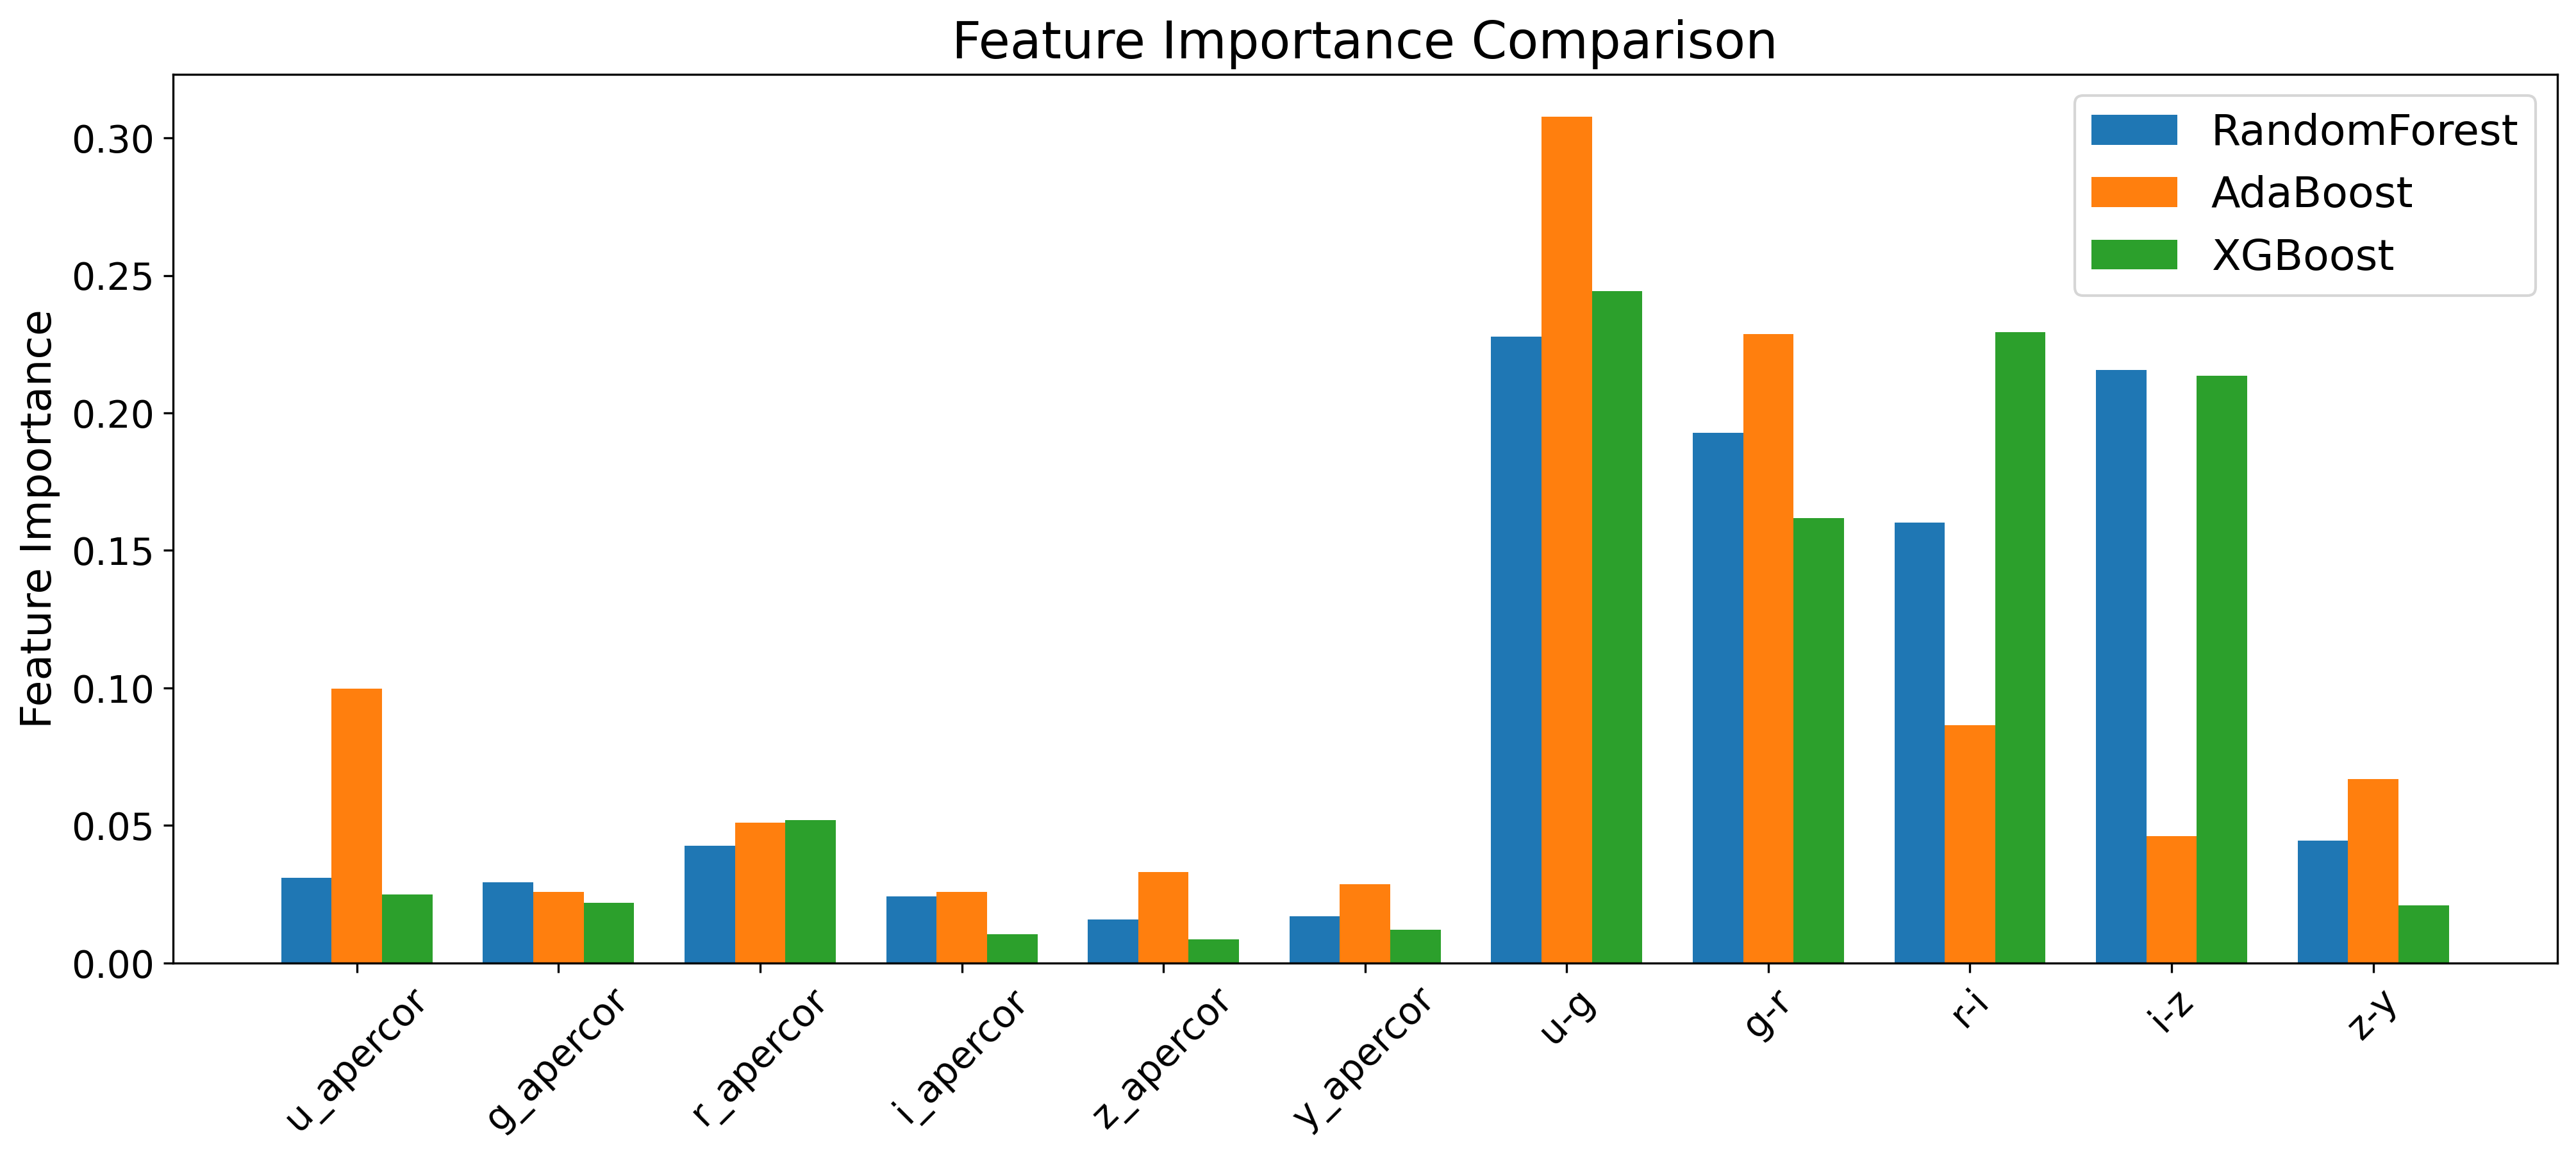

In [14]:
importances_rf = rf_model.feature_importances_

ab_model = AdaBoostRegressor(n_estimators=200, random_state=42)
ab_model.fit(X_train, y_train)
importances_ab = ab_model.feature_importances_

xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)
importances_xgb = xgb_model.feature_importances_

plt.figure(figsize=(16,6))
width = 0.25
x = np.arange(features_v3.shape[1])

plt.bar(x - width, importances_rf, width=width, label='RandomForest')
plt.bar(x, importances_ab, width=width, label='AdaBoost')
plt.bar(x + width, importances_xgb, width=width, label='XGBoost')

plt.xticks(x, features_v3.columns, rotation=45)
plt.ylabel("Feature Importance")
plt.title("Feature Importance Comparison")
plt.legend()
plt.show()

### Acknowledgement statement:

>ChatGPT was used for assistance in drafting code. 